DSCI 552 Homework 1
===================

- Name: Rudrani Chavarkar
- GitHub Username: rudranichav
- USD ID: 3158-2107-65

Vertebral Column Data

### (a) Download Data

Package imports

In [175]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



In this section, I import all the libraries needed for the assignment, including
numpy and pandas for data handling, matplotlib for plotting, and scikit-learn
for KNN classification and evaluation. I also suppress warning messages so that
the output is easier to read.


In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, f1_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

Get the Vertebral Column Data Set

In [177]:
df = pd.read_csv('../data/column_2C.dat', header=None, delim_whitespace=True)
df.head()


,0,1,2,3,4,5,6
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


In [178]:
df.columns = [
    "pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle",
    "sacral_slope", "pelvic_radius", "grade_of_spondylolisthesis", "class"
]

print("Shape:", df.shape)
df.head()

Shape: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


I keep only the "NO" and "AB"
classes as required, map them to numerical labels (NO -> 0, AB -> 1), and create
the feature matrix X and label vector y. Finally, I print the dataset size to
confirm the data was loaded correctly.

In [179]:
# Map class labels: NO -> 0, AB -> 1 (we only keep NO and AB rows)
keep = df['class'].isin(['NO', 'AB'])
df = df[keep].copy()
df['label'] = df['class'].map({'NO': 0, 'AB': 1})
X = df[df.columns[:-1]].values
y = df['label'].values

print('Loaded dataset: rows =', df.shape[0], 'features =', X.shape[1])


Loaded dataset: rows = 310 features = 7


In [180]:
df

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class,label
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB,1
1,39.06,10.06,25.02,29.00,114.41,4.56,AB,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB,1
3,69.30,24.65,44.31,44.64,101.87,11.21,AB,1
4,49.71,9.65,28.32,40.06,108.17,7.92,AB,1
...,...,...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25,NO,0
306,53.94,20.72,29.22,33.22,114.37,-0.42,NO,0
307,61.45,22.69,46.17,38.75,125.67,-2.71,NO,0
308,45.25,8.69,41.58,36.56,118.55,0.21,NO,0


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

In this part, I perform exploratory data analysis. I first generate a scatter
matrix of all feature pairs, with points colored by class label, to visually
inspect class separability and feature relationships.

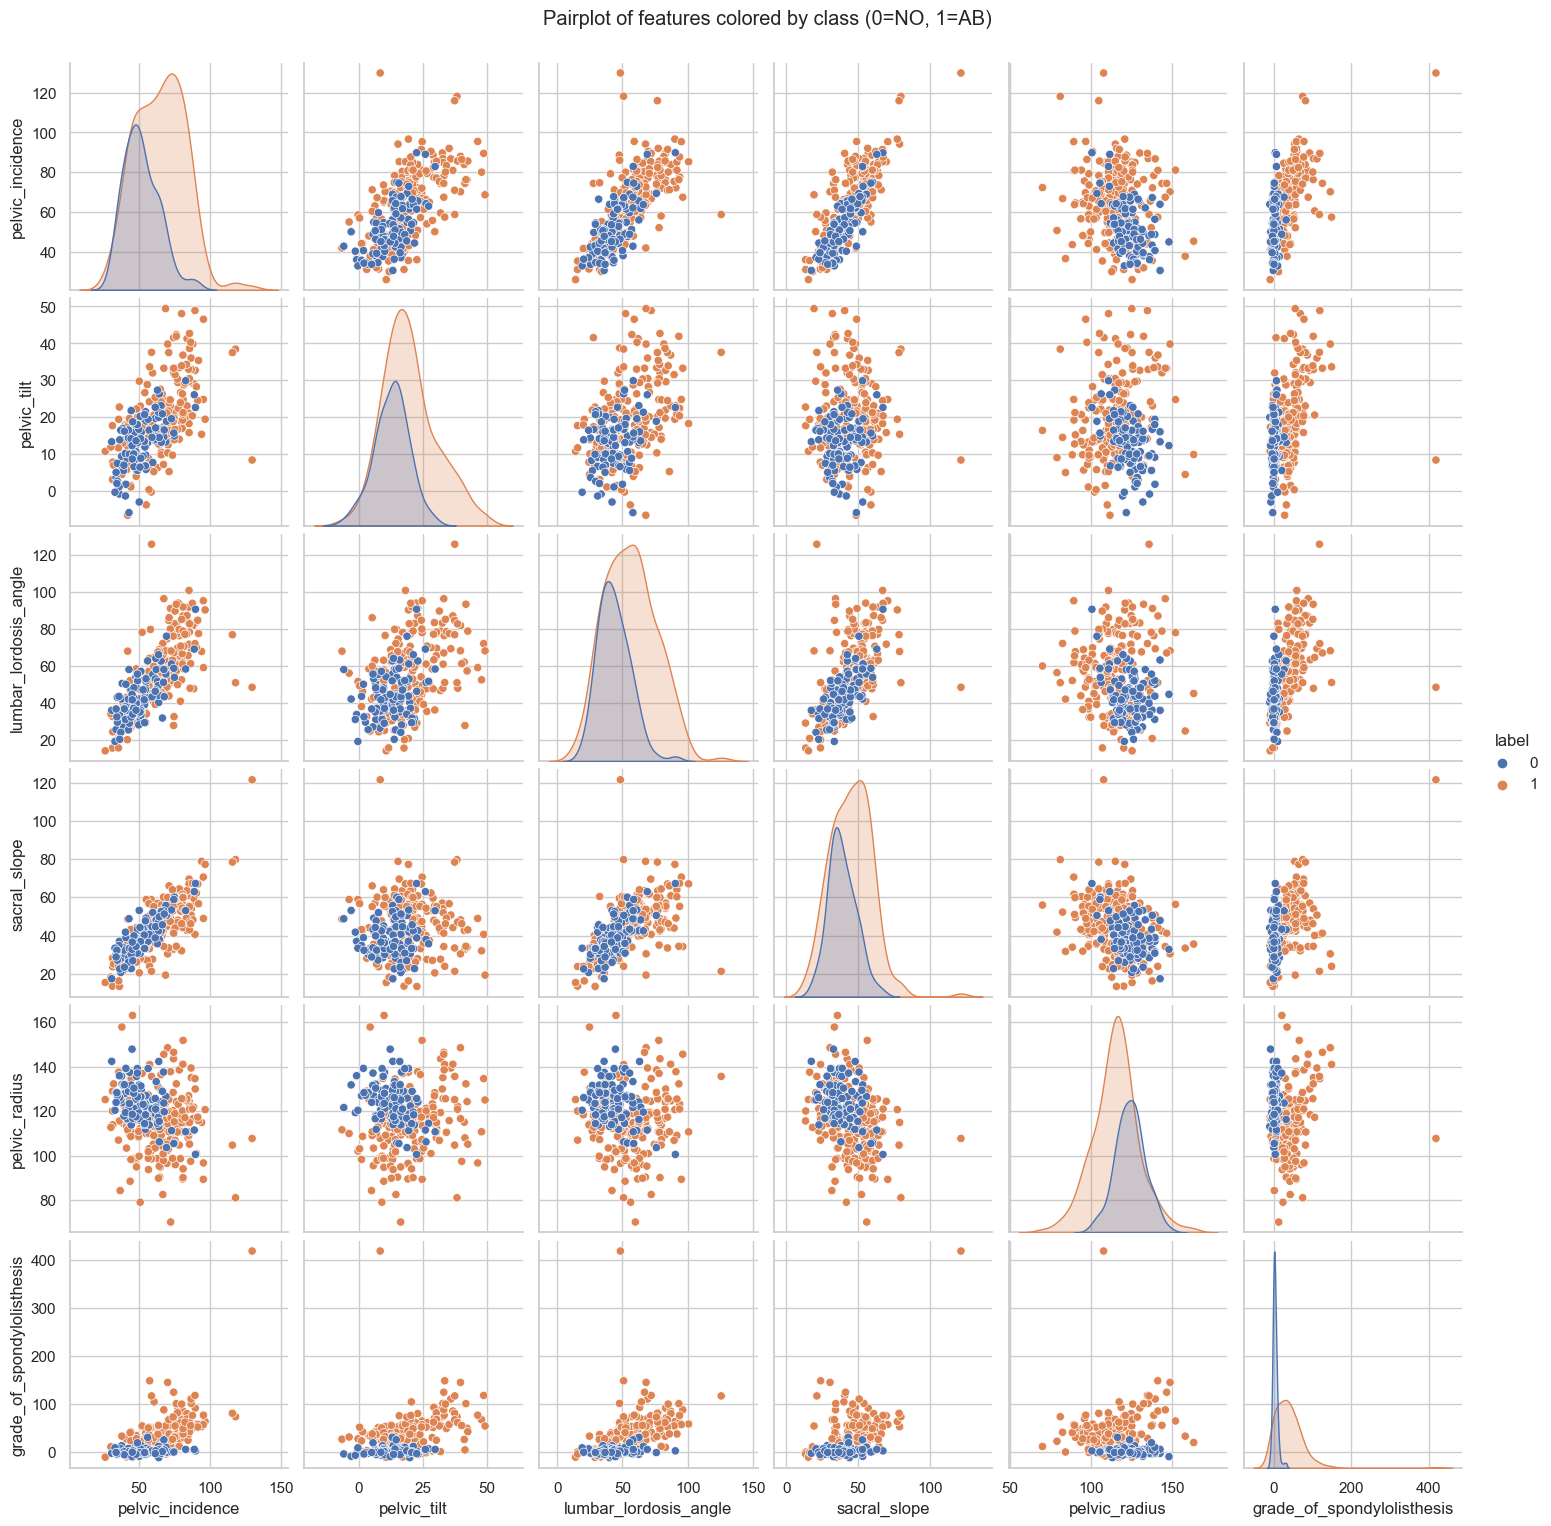

In [181]:
sns.pairplot(df, hue='label',diag_kind = 'kde')
plt.suptitle("Pairplot of features colored by class (0=NO, 1=AB)", y=1.02)
plt.show()



#### ii. Boxplots

Then, I create boxplots
for each feature grouped by class to compare distributions and identify outliers.

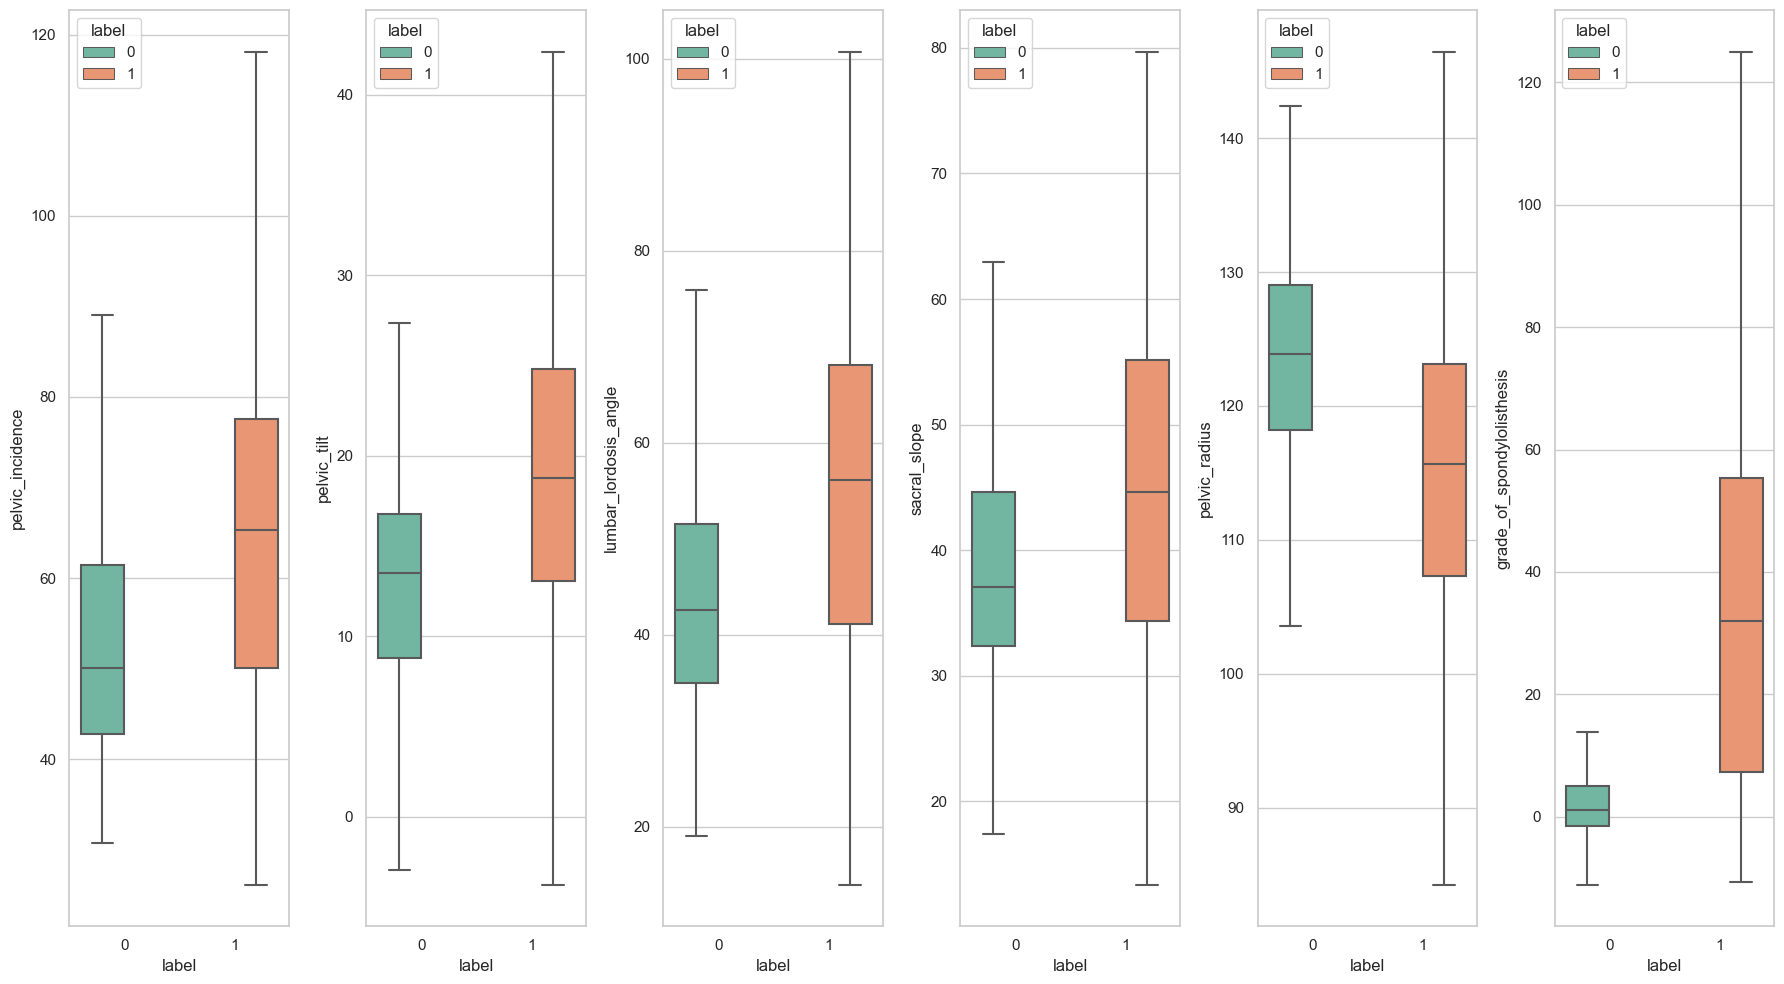

In [182]:
figure, axes = plt.subplots(1,6,figsize=(18,10))

for i,col in enumerate(df.columns[:-2]):
  sns.boxplot(x='label', y=col, data=df, hue ='label',ax=axes[i], showfliers=False, palette='Set2')

plt.tight_layout()
plt.show()

#### iii. Split Data Set

I select the first 70 samples from class 0 (NO) and the first 140 samples from
class 1 (AB) as the training set, preserving the original data order. All remaining
samples are used for testing. I then construct X_train, y_train, X_test, and y_test
and print their sizes to verify the split.

In [183]:
idx_class0 = df[df['label'] == 0].index.tolist()
idx_class1 = df[df['label'] == 1].index.tolist()

train_idx = idx_class0[:70] + idx_class1[:140]
test_idx = [i for i in df.index if i not in train_idx]

X = df[df.columns[:-2]].values
y = df['label'].values

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

print("Train sizes:", X_train.shape, "Test sizes:", X_test.shape)


Train sizes: (210, 6) Test sizes: (100, 6)


### (c) Classification

#### i. Euclidean Metric

Here, I train k-NN classifiers using Euclidean distance for a range of k values.
For each k, I compute both the training error and test error. I then plot these
error rates as a function of k to visualize underfitting and overfitting behavior.
The best k is chosen as the one that minimizes the test error.

In [184]:
max_k = min(208, X_train.shape[0])
ks = list(range(max_k, 0, -3))
train_errs = []
test_errs = []

print("Evaluating k-NN for k values:", ks)

Evaluating k-NN for k values: [208, 205, 202, 199, 196, 193, 190, 187, 184, 181, 178, 175, 172, 169, 166, 163, 160, 157, 154, 151, 148, 145, 142, 139, 136, 133, 130, 127, 124, 121, 118, 115, 112, 109, 106, 103, 100, 97, 94, 91, 88, 85, 82, 79, 76, 73, 70, 67, 64, 61, 58, 55, 52, 49, 46, 43, 40, 37, 34, 31, 28, 25, 22, 19, 16, 13, 10, 7, 4, 1]


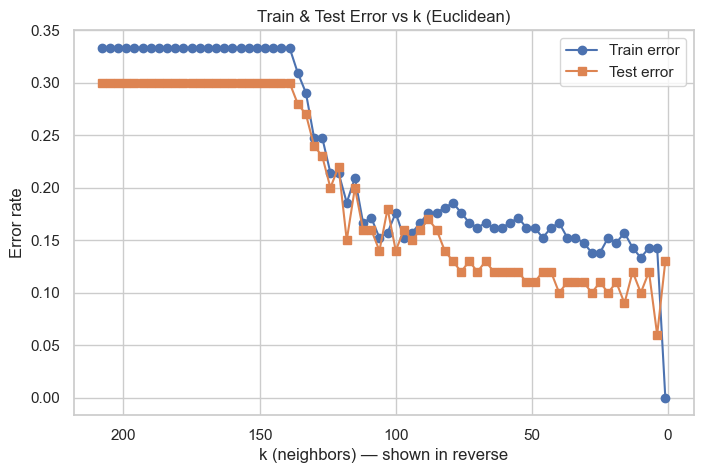

In [185]:
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    clf.fit(X_train, y_train)
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    train_errs.append(1 - np.mean(train_pred == y_train))
    test_errs.append(1 - np.mean(test_pred == y_test))


plt.figure(figsize=(8, 5))
plt.plot(ks, train_errs, marker='o', label='Train error')
plt.plot(ks, test_errs, marker='s', label='Test error')
plt.gca().invert_xaxis() # since ks are in reverse order
plt.xlabel('k (neighbors) — shown in reverse')
plt.ylabel('Error rate')
plt.title('Train & Test Error vs k (Euclidean)')
plt.legend()
plt.show()

In [186]:
min_test = min(test_errs)
best_indices = [i for i,v in enumerate(test_errs) if v == min_test]
best_idx = best_indices[0]
best_k = ks[best_idx]
print('Best k according to test error:', best_k)
print('Test Error =', min_test)

Best k according to test error: 4
Test Error = 0.06000000000000005


#### ii. Test Data

Using the best k selected above, I evaluate the classifier on the test set.
I compute and print the confusion matrix, along with performance metrics including
true positive rate (recall for AB), true negative rate (for NO), precision, and
F1-score, to fully assess the classifier’s performance.

In [187]:
best_clf = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_clf.fit(X_train, y_train)
y_pred_best = best_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best) # this is TP rate for positive class
tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]
tp = cm[1,1]
true_positive_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
true_negative_rate = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_test, y_pred_best)


print('\nConfusion matrix (rows: true, cols: pred)\n', cm)
print('True Positive Rate (Recall for AB=1):', true_positive_rate)
print('True Negative Rate (for NO=0):', true_negative_rate)
print('Precision (AB=1):', precision)
print('F1-score (AB=1):', f1)


Confusion matrix (rows: true, cols: pred)
 [[25  5]
 [ 1 69]]
True Positive Rate (Recall for AB=1): 0.9857142857142858
True Negative Rate (for NO=0): 0.8333333333333334
Precision (AB=1): 0.9324324324324325
F1-score (AB=1): 0.9583333333333333


#### iii. Learning Curve

I study how the classifier performance changes with the size of
the training set. For increasing values of N, I construct smaller training subsets
(approximately one-third from class 0 and the remainder from class 1), search over
candidate k values, and record the lowest test error achieved. I then plot the best
test error versus N to produce a learning curve.

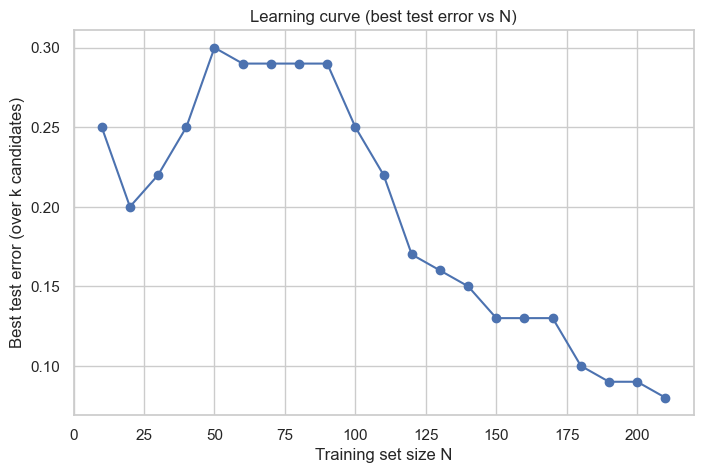

In [188]:
Ns = list(range(10, min(210, X_train.shape[0]) + 1, 10))
best_test_for_N = []
for N in Ns:
# choose first floor(N/3) from class 0 and remainder from class 1 from our training set ordering
    n0 = N // 3
    n1 = N - n0
    # get indices relative to our training set ordering
    idx0 = [i for i,val in enumerate(y_train) if val == 0][:n0]
    idx1 = [i for i,val in enumerate(y_train) if val == 1][:n1]
    if len(idx0) < n0 or len(idx1) < n1:
        # not enough samples of a class to make this N; skip
        best_test_for_N.append(np.nan)
        continue
    chosen_idx = idx0 + idx1
    X_sub = X_train[chosen_idx]
    y_sub = y_train[chosen_idx]
    # Evaluate k candidates
    candidate_ks = list(range(1, min(196, X_sub.shape[0]) + 1, 5))
    best_err = 1.0
    for k in candidate_ks:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_sub, y_sub)
        testp = clf.predict(X_test)
        err = 1 - np.mean(testp == y_test)
        if err < best_err:
            best_err = err  
    best_test_for_N.append(best_err)


plt.figure(figsize=(8,5))
plt.plot(Ns, best_test_for_N, marker='o')
plt.xlabel('Training set size N')
plt.ylabel('Best test error (over k candidates)')
plt.title('Learning curve (best test error vs N)')
plt.show()

### (d) Other Metrics

Here, I experiment with alternative distance metrics for k-NN. This includes
Manhattan distance (Minkowski p=1), Minkowski distance with varying p values,
Chebyshev distance, and Mahalanobis distance using the covariance matrix of the
training data. For each metric, I search for the best k and record the corresponding
test error, and then print a summary of the results.

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [189]:
summary = []

ks_candidates = list(range(1, min(196, X_train.shape[0]) + 1, 5))
best_err_manhattan = 1.0
best_k_manhattan = None
for k in ks_candidates:
    clf = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1)
    clf.fit(X_train, y_train)
    err = 1 - np.mean(clf.predict(X_test) == y_test)
    if err < best_err_manhattan:
        best_k_manhattan = k
        best_err_manhattan = err
summary.append(('Manhattan (p=1)', best_k_manhattan, best_err_manhattan))

##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [190]:
log10_values = np.round(np.arange(0.1, 1.01, 0.1), 2)
best_p = None
best_err_p = 1.0
for lv in log10_values:
    p = 10 ** lv
    # use best_k from Manhattan as starting; but instructions said: use k* found for Manhattan
    k_use = best_k_manhattan
    clf = KNeighborsClassifier(n_neighbors=k_use, metric='minkowski', p=p)
    clf.fit(X_train, y_train)
    err = 1 - np.mean(clf.predict(X_test) == y_test)
    if err < best_err_p:
        best_err_p = err
        best_p = p
summary.append(('Minkowski varying p (searched log10 p)', best_k_manhattan, best_err_p, best_p))

##### C. Chebyshev Distance With p -> infinity.

In [191]:
best_err_cheb = 1.0
best_k_cheb = None
for k in ks_candidates:
    clf = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    clf.fit(X_train, y_train)
    err = 1 - np.mean(clf.predict(X_test) == y_test)
    if err < best_err_cheb:
        best_err_cheb = err
        best_k_cheb = k
summary.append(('Chebyshev', best_k_cheb, best_err_cheb))

#### ii. Mahalanobis Distance.

In [192]:

cov = np.cov(X_train, rowvar=False)
inv_cov = np.linalg.pinv(cov)

best_err_mah = 1.0
best_k_mah = None

for k in ks_candidates:
    clf = KNeighborsClassifier(
        n_neighbors=k,
        metric='mahalanobis',
        metric_params={'VI': inv_cov}
    )
    clf.fit(X_train, y_train)
    err = 1 - np.mean(clf.predict(X_test) == y_test)
    if err < best_err_mah:
        best_err_mah = err
        best_k_mah = k

summary.append(('Mahalanobis', best_k_mah, best_err_mah))

In [193]:
print('\nDistance summary (best k and test error):')
for row in summary:
    print(row)


Distance summary (best k and test error):
('Manhattan (p=1)', 6, 0.10999999999999999)
('Minkowski varying p (searched log10 p)', 6, 0.06000000000000005, 3.9810717055349722)
('Chebyshev', 16, 0.07999999999999996)
('Mahalanobis', 1, 0.17000000000000004)


### (e) Weighted Decision

In this part, I evaluate distance-weighted k-NN classifiers, where closer neighbors
have more influence on the prediction. I repeat the k search for Euclidean,
Manhattan, and Chebyshev distances, record the best test error for each case,
and print the results for comparison with unweighted voting.

In [194]:
weighted_summary = []
for metric in ['euclidean', 'minkowski', 'chebyshev']:
    best_err = 1.0
    best_k = None
    for k in ks_candidates:
        if metric == 'minkowski':
            clf = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1, weights='distance')
        else:
            clf = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        clf.fit(X_train, y_train)
        err = 1 - np.mean(clf.predict(X_test) == y_test)
        if err < best_err:
            best_err = err
            best_k = k
    weighted_summary.append((metric, best_k, best_err))

In [195]:
print('\nWeighted voting results:')
for row in weighted_summary:
    print(row)


Weighted voting results:
('euclidean', 6, 0.09999999999999998)
('minkowski', 26, 0.09999999999999998)
('chebyshev', 16, 0.10999999999999999)


### (f) Training Error Rate

Finally, I search over small values of k to find the minimum training error achieved
by k-NN on the training data. This helps illustrate how k-NN can overfit when k is
very small. The lowest training error found is printed.

In [196]:
min_train_err = 1.0
for k in range(1, min(30, X_train.shape[0]) + 1):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    err = 1 - np.mean(clf.predict(X_train) == y_train)
    if err < min_train_err:
        min_train_err = err

print('\nLowest training error found:', min_train_err)


Lowest training error found: 0.0
